# 06 Lyrics Features EDA

This notebook explores the lyrics-related information in the Spotify dataset.

The analysis focuses on:
- lyrics availability and structure
- text characteristics
- word and lyric length distributions
- relationships between lyrics and popularity
- how lyrical information may support the recommendation system

## 1. Load Lyrics Data

In [1]:
from pathlib import Path
import sys
import warnings

import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

plt.style.use("ggplot")

sns.set_theme(
    style="whitegrid",
    palette="deep"
)

PROJECT_ROOT = Path.cwd().parents[0] if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(PROJECT_ROOT))

from config.paths import DUCKDB_PATH

con = duckdb.connect(DUCKDB_PATH)

In [2]:
lyrics_df = con.execute("""
    SELECT *
    FROM tracks
""").df()

lyrics_df.shape

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

(101939, 32)

In [3]:
lyrics_df.head()

,column00,acousticness,album_id,analysis_url,artists_id,available_markets,country,danceability,disc_number,duration_ms,...,preview_url,speechiness,tempo,time_signature,track_href,track_name_prev,track_number,uri,valence,type
0,0,0.294,0D3QufeCudpQANOR7luqdr,https://api.spotify.com/v1/audio-analysis/5qlj...,['3mxJuHRn2ZWD5OofvJtDZY'],"['AD', 'AE', 'AR', 'AT', 'AU', 'BE', 'BG', 'BH...",BE,0.698,1.0,235584.0,...,https://p.scdn.co/mp3-preview/1b05a902da3a251d...,0.0262,115.018,4.0,https://api.spotify.com/v1/tracks/5qljLQuKnNJf...,track_14,1.0,spotify:track:5qljLQuKnNJf4F4vfxQB0V,0.6220,track
1,1,0.863,1bcqsH5UyTBzmh9YizdsBE,https://api.spotify.com/v1/audio-analysis/3VAX...,['4xWMewm6CYMstu0sPgd9jJ'],"['AD', 'AE', 'AR', 'AT', 'AU', 'BE', 'BG', 'BH...",BE,0.719,1.0,656960.0,...,https://p.scdn.co/mp3-preview/d8140736a6131cb5...,0.9220,115.075,3.0,https://api.spotify.com/v1/tracks/3VAX2MJdmdqA...,track_3,3.0,spotify:track:3VAX2MJdmdqARLSU5hPMpm,0.5890,track
2,2,0.750,4tKijjmxGClg4JOLAyo2qE,https://api.spotify.com/v1/audio-analysis/1L3Y...,['3hYaK5FF3YAglCj5HZgBnP'],['GB'],BE,0.466,1.0,492840.0,...,https://p.scdn.co/mp3-preview/c8af28fb15185b18...,0.9440,79.565,4.0,https://api.spotify.com/v1/tracks/1L3YAhsEMrGV...,track_4,4.0,spotify:track:1L3YAhsEMrGVvCgDXj2TYn,0.0850,track
3,3,0.763,6FeJF5r8roonnKraJxr4oB,https://api.spotify.com/v1/audio-analysis/6aCe...,['2KQsUB9DRBcJk17JWX1eXD'],"['AD', 'AE', 'AR', 'AT', 'AU', 'BE', 'BG', 'BH...",BE,0.719,1.0,316578.0,...,https://p.scdn.co/mp3-preview/7629b8e9f31f6e9b...,0.9380,112.822,3.0,https://api.spotify.com/v1/tracks/6aCe9zzoZmCo...,track_9,1.0,spotify:track:6aCe9zzoZmCojX7bbgKKtf,0.5330,track
4,4,0.770,4tKijjmxGClg4JOLAyo2qE,https://api.spotify.com/v1/audio-analysis/1Vo8...,['3hYaK5FF3YAglCj5HZgBnP'],['GB'],BE,0.460,1.0,558880.0,...,https://p.scdn.co/mp3-preview/32be593c0eb82868...,0.9430,81.260,4.0,https://api.spotify.com/v1/tracks/1Vo802A38tPF...,track_2,2.0,spotify:track:1Vo802A38tPFHmje1h91um,0.0906,track


## 2. Basic Dataset Information

In [4]:
lyrics_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101939 entries, 0 to 101938
Data columns (total 32 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   column00           101939 non-null  int64  
 1   acousticness       101939 non-null  float64
 2   album_id           101939 non-null  object 
 3   analysis_url       101939 non-null  object 
 4   artists_id         101939 non-null  object 
 5   available_markets  101939 non-null  object 
 6   country            101939 non-null  object 
 7   danceability       101939 non-null  float64
 8   disc_number        101939 non-null  float64
 9   duration_ms        101939 non-null  float64
 10  energy             101939 non-null  float64
 11  href               101939 non-null  object 
 12  id                 101939 non-null  object 
 13  instrumentalness   101939 non-null  float64
 14  key                101939 non-null  float64
 15  liveness           101939 non-null  float64
 16  lo

In [5]:
lyrics_df.describe(include="all")

,column00,acousticness,album_id,analysis_url,artists_id,available_markets,country,danceability,disc_number,duration_ms,...,preview_url,speechiness,tempo,time_signature,track_href,track_name_prev,track_number,uri,valence,type
count,101939.000000,101939.000000,101939,101939,101939,101939,101939,101939.000000,101939.000000,1.019390e+05,...,101939,101939.000000,101939.000000,101939.000000,101939,101939,101939.000000,101939,101939.000000,101939
unique,NaN,NaN,75503,101939,54673,3181,3,NaN,NaN,NaN,...,99728,NaN,NaN,NaN,101939,100,NaN,101939,NaN,1
top,NaN,NaN,65ujg0YuXfO1usl4EPhqVY,https://api.spotify.com/v1/audio-analysis/5qlj...,['0LyfQWJT6nXafLPZqxe9Of'],"['AD', 'AE', 'AR', 'AT', 'AU', 'BE', 'BG', 'BH...",AR,NaN,NaN,NaN,...,https://p.scdn.co/mp3-preview/924e366ee6b2ded7...,NaN,NaN,NaN,https://api.spotify.com/v1/tracks/5qljLQuKnNJf...,track_12,NaN,spotify:track:5qljLQuKnNJf4F4vfxQB0V,NaN,track
freq,NaN,NaN,100,1,284,65351,50437,NaN,NaN,NaN,...,6,NaN,NaN,NaN,1,2241,NaN,1,NaN,101939
mean,50969.000000,0.352124,NaN,NaN,NaN,NaN,NaN,0.586015,1.032166,2.467708e+05,...,NaN,0.128841,118.358527,3.875651,NaN,NaN,4.608060,NaN,0.482813,NaN
std,29427.398883,0.334855,NaN,NaN,NaN,NaN,NaN,0.177724,0.566789,1.904303e+05,...,NaN,0.203324,30.224074,0.517008,NaN,NaN,7.181805,NaN,0.261690,NaN
min,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,0.000000,1.000000,1.155000e+03,...,NaN,0.000000,0.000000,0.000000,NaN,NaN,1.000000,NaN,0.000000,NaN
25%,25484.500000,0.040700,NaN,NaN,NaN,NaN,NaN,0.480000,1.000000,1.840000e+05,...,NaN,0.036400,95.973000,4.000000,NaN,NaN,1.000000,NaN,0.271000,NaN
50%,50969.000000,0.238000,NaN,NaN,NaN,NaN,NaN,0.610000,1.000000,2.168930e+05,...,NaN,0.050600,118.067000,4.000000,NaN,NaN,2.000000,NaN,0.477000,NaN
75%,76453.500000,0.645000,NaN,NaN,NaN,NaN,NaN,0.714000,1.000000,2.610550e+05,...,NaN,0.104000,136.045000,4.000000,NaN,NaN,6.000000,NaN,0.693000,NaN


In [6]:
lyrics_df.isnull().sum().sort_values(ascending=False)

column00             0
acousticness         0
valence              0
uri                  0
track_number         0
track_name_prev      0
track_href           0
time_signature       0
tempo                0
speechiness          0
preview_url          0
popularity           0
playlist             0
name                 0
mode                 0
lyrics               0
loudness             0
liveness             0
key                  0
instrumentalness     0
id                   0
href                 0
energy               0
duration_ms          0
disc_number          0
danceability         0
country              0
available_markets    0
artists_id           0
analysis_url         0
album_id             0
type                 0
dtype: int64

In [7]:
lyrics_df.duplicated().sum()

0

## 3. Lyrics Column Exploration

In [8]:
lyrics_df["lyrics"].head()

0    \r\n\r\nPerhaps I am bound to be restless\r\nA...
1    \r\nYour Gods and my Gods-do you or I know whi...
2    \r\n\r\nClosed off from love, I didn't need th...
3    \r\nPAIN, n. An uncomfortable frame of mind th...
4    \r\n\r\nClosed off from love, I didn't need th...
Name: lyrics, dtype: object

In [9]:
lyrics_df["lyrics"].dtype

dtype('O')

In [10]:
lyrics_df["lyrics"].apply(type).value_counts()

lyrics
<class 'str'>    101939
Name: count, dtype: int64

## 4. Lyrics Availability

In [11]:
lyrics_df["has_lyrics"] = lyrics_df["lyrics"].apply(
    lambda x: 0 if str(x).strip() == "" else 1
)

lyrics_df["has_lyrics"].value_counts()

has_lyrics
1    101140
0       799
Name: count, dtype: int64

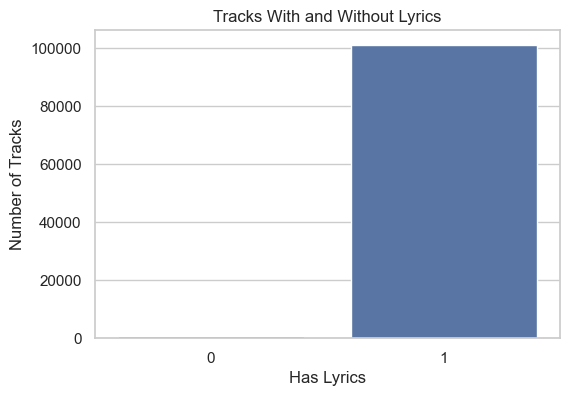

In [12]:
plt.figure(figsize=(6, 4))

sns.countplot(
    data=lyrics_df,
    x="has_lyrics"
)

plt.title("Tracks With and Without Lyrics")
plt.xlabel("Has Lyrics")
plt.ylabel("Number of Tracks")

plt.show()

## 5. Lyrics Length Features

In [13]:
lyrics_df["lyrics_char_count"] = (
    lyrics_df["lyrics"]
    .astype(str)
    .apply(len)
)

In [14]:
lyrics_df["lyrics_word_count"] = (
    lyrics_df["lyrics"]
    .astype(str)
    .apply(lambda x: len(x.split()))
)

In [15]:
lyrics_df[
    ["lyrics_char_count", "lyrics_word_count"]
].describe()

,lyrics_char_count,lyrics_word_count
count,101939.000000,101939.000000
mean,1588.708080,298.214363
std,4623.977585,825.988404
min,3.000000,0.000000
25%,655.000000,123.000000
50%,1176.000000,224.000000
75%,1740.000000,331.000000
max,226732.000000,38062.000000


In [16]:
lyrics_df[
    ["lyrics", "lyrics_char_count", "lyrics_word_count"]
].head()

,lyrics,lyrics_char_count,lyrics_word_count
0,\r\n\r\nPerhaps I am bound to be restless\r\nA...,1059,201
1,\r\nYour Gods and my Gods-do you or I know whi...,27145,4959
2,"\r\n\r\nClosed off from love, I didn't need th...",2012,376
3,"\r\nPAIN, n. An uncomfortable frame of mind th...",24202,3865
4,"\r\n\r\nClosed off from love, I didn't need th...",2012,376


## 6. Distribution of Lyrics Length

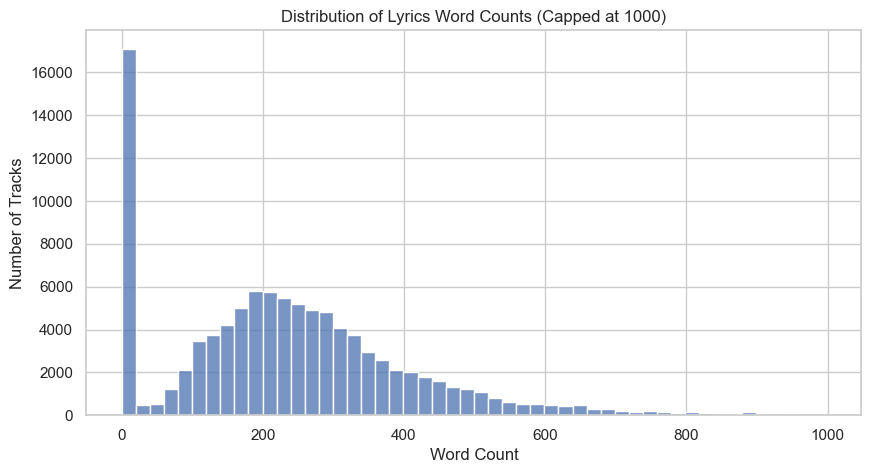

In [20]:
plt.figure(figsize=(10, 5))

sns.histplot(
    lyrics_df[
        lyrics_df["lyrics_word_count"] < 1000
    ]["lyrics_word_count"],
    bins=50
)

plt.title("Distribution of Lyrics Word Counts (Capped at 1000)")
plt.xlabel("Word Count")
plt.ylabel("Number of Tracks")

plt.show()

The distribution is capped at 1000 words because a small number of extreme outliers contain unusually large text entries. These may represent spoken-word content, poems, or incorrectly scraped lyrics rather than standard song lyrics.

## 7. Numerical Feature Detection

In [18]:
numeric_cols = lyrics_df.select_dtypes(
    include=["int64", "float64"]
).columns

numeric_cols.tolist()

['column00',
 'acousticness',
 'danceability',
 'disc_number',
 'duration_ms',
 'energy',
 'instrumentalness',
 'key',
 'liveness',
 'loudness',
 'mode',
 'popularity',
 'speechiness',
 'tempo',
 'time_signature',
 'track_number',
 'valence',
 'has_lyrics',
 'lyrics_char_count',
 'lyrics_word_count']

In [19]:
print("Total numerical columns:", len(numeric_cols))

Total numerical columns: 20


## 8. Relationship Between Lyrics Length and Popularity

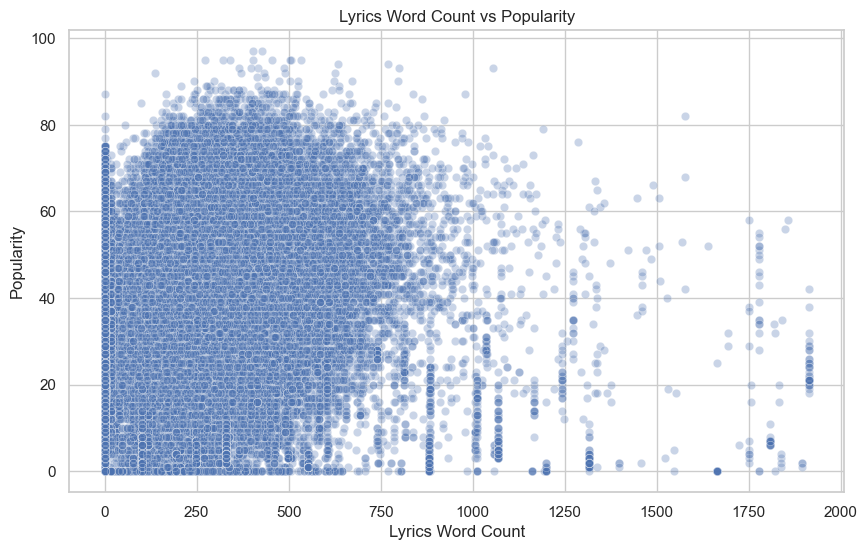

In [21]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=lyrics_df[
        lyrics_df["lyrics_word_count"] < 2000
    ],
    x="lyrics_word_count",
    y="popularity",
    alpha=0.3
)

plt.title("Lyrics Word Count vs Popularity")
plt.xlabel("Lyrics Word Count")
plt.ylabel("Popularity")

plt.show()

The relationship between lyrics length and popularity appears relatively weak. Most songs cluster between 100 and 700 words regardless of popularity level.

This suggests that lyrical length alone is not a strong predictor of commercial success, although it may still contribute useful contextual information for recommendation systems or future NLP analysis.

## 9. Most Extreme Lyrics Entries

In [22]:
lyrics_df.sort_values(
    by="lyrics_word_count",
    ascending=False
)[
    ["name", "lyrics_word_count", "popularity"]
].head(10)

,name,lyrics_word_count,popularity
66190,Hard to Say I'm Sorry / Get Away - Remastered,38062,42.0
89199,Sutsisatsi,38062,40.0
79766,Hard to Say I'm Sorry - 2007 Remaster,38062,65.0
101021,Lähestyy,38062,27.0
89195,Matkalla,38062,24.0
91959,Street Player - Remastered,38062,48.0
66241,25 or 6 to 4 - Remastered,38062,63.0
41390,Kig Forbi,24955,40.0
86608,Love Will Keep Us Together,23366,29.0
5887,Psalm 60,22474,9.0


Several tracks contain extremely large lyrics entries that are unlikely to represent normal song lyrics. 

Some entries exceed 38,000 words and appear repeatedly across different songs, suggesting possible scraping issues, duplicated text blocks, or metadata inconsistencies.

These observations highlight the importance of preprocessing and cleaning textual data before applying advanced NLP techniques.

## 10. Lyrics Length Categories

In [23]:
lyrics_df["lyrics_length_group"] = pd.cut(
    lyrics_df["lyrics_word_count"],
    bins=[0, 100, 300, 600, 1000, 50000],
    labels=[
        "Very Short",
        "Short",
        "Medium",
        "Long",
        "Very Long"
    ]
)

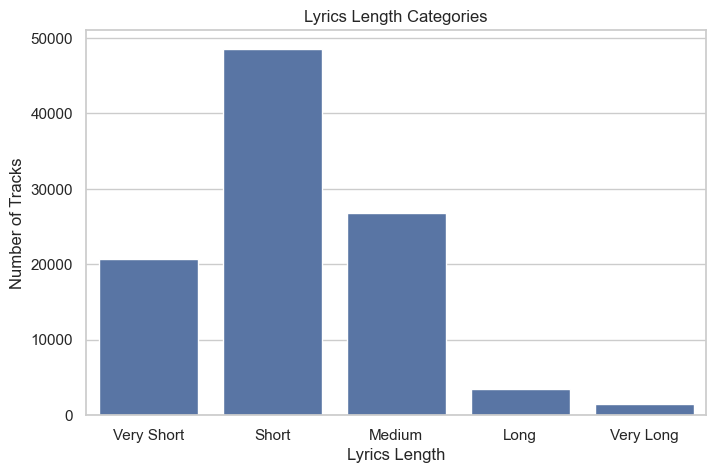

In [24]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=lyrics_df,
    x="lyrics_length_group",
    order=[
        "Very Short",
        "Short",
        "Medium",
        "Long",
        "Very Long"
    ]
)

plt.title("Lyrics Length Categories")
plt.xlabel("Lyrics Length")
plt.ylabel("Number of Tracks")

plt.show()

Most tracks fall into the Short or Medium lyrics categories, indicating that the dataset mainly contains standard song structures. 

Only a small number of tracks contain extremely large amounts of text, which likely represent spoken-word recordings, poems, or unusually long lyrical entries.

## 11. Compare Popular vs Non-Popular Songs

In [25]:
lyrics_df["popular_group"] = (
    lyrics_df["popularity"] >= 60
)

In [26]:
lyrics_df.groupby(
    "popular_group"
)[
    ["lyrics_word_count", "lyrics_char_count"]
].mean()

,lyrics_word_count,lyrics_char_count
popular_group,,
False,296.067584,1581.857321
True,313.986244,1639.038975


Popular songs contain slightly longer lyrics on average compared to less popular songs. However, the difference is relatively small, suggesting that lyrical length alone does not strongly determine popularity.

## 12. Lexical Diversity

In [29]:
lyrics_df[
    ["lexical_diversity"]
].describe()

,lexical_diversity
count,101939.000000
mean,0.502872
std,0.250045
min,0.000000
25%,0.333333
50%,0.430168
75%,0.588517
max,1.000000


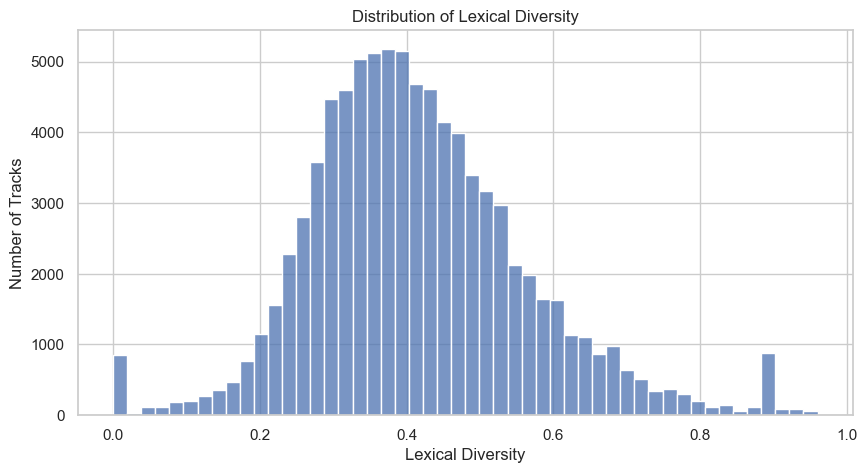

In [30]:
plt.figure(figsize=(10, 5))

sns.histplot(
    lyrics_df[
        lyrics_df["lexical_diversity"] < 1
    ]["lexical_diversity"],
    bins=50
)

plt.title("Distribution of Lexical Diversity")
plt.xlabel("Lexical Diversity")
plt.ylabel("Number of Tracks")

plt.show()

The lexical diversity distribution shows that most songs contain moderate vocabulary variation, with many tracks clustering between 0.3 and 0.6.

Lower values generally indicate more repetitive lyrical structures, such as repeated choruses or hooks, while higher values suggest more varied vocabulary and potentially more complex lyrical content.

A small number of extreme values near 1.0 may represent spoken-word recordings, poems, or unusually structured text entries.

## Potential future extensions could include:
- sentiment analysis
- lyrical similarity
- TF-IDF vectorization
- topic modeling
- transformer-based embeddings